### I place under data folder / results folder which includes all csv files and two tables!

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

AREAS = ["V1", "V4", "IT"]

# Make paths work wherever this notebook is run from 
for candidate in [
    Path.cwd(),
    Path.cwd() / "results",
    Path.cwd() / "diffusion_brain_alignment" / "data" / "results",
    Path.cwd().parent / "diffusion_brain_alignment" / "data" / "results",
]:
    if (candidate / "Monkeys_Results.xlsx").exists():
        DATA = candidate
        break
else:
    raise FileNotFoundError("Could not find Monkeys_Results.xlsx. Check the notebook working directory.")


In [ ]:
# This needs to be run once
#!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [40]:
monkey = pd.read_excel(DATA / "Monkeys_Results.xlsx")
monkey["ROI"] = pd.Categorical(monkey["ROI"], categories=AREAS, ordered=True)
monkey = monkey.sort_values("ROI")
monkey

,monkey1,monkey2,ROI,common_images,rdm_metric,compare_method,rsa_score
0,monkeyF,monkeyN,V1,1854,correlation,corr_cov,0.416051
3,monkeyF,monkeyN,V1,1854,correlation,rho-a,0.395779
6,monkeyF,monkeyN,V1,1854,euclidean,corr_cov,0.616705
9,monkeyF,monkeyN,V1,1854,euclidean,rho-a,0.481266
12,monkeyF,monkeyN,V1,100,crossnobis,rho-a,0.766806
1,monkeyF,monkeyN,V4,1854,correlation,corr_cov,0.333828
4,monkeyF,monkeyN,V4,1854,correlation,rho-a,0.308943
7,monkeyF,monkeyN,V4,1854,euclidean,corr_cov,0.416631
10,monkeyF,monkeyN,V4,1854,euclidean,rho-a,0.342586
13,monkeyF,monkeyN,V4,100,crossnobis,rho-a,0.558343


In [28]:
sig = pd.read_excel(DATA / "Statistical_Significance.xlsx")
sig

,monkey,roi,noise_degree,total_images,rdm_metric,compare_method,n_permutations,random_seed,true_alignment_score,p_value
0,monkeyF,IT,0.1,1854,correlation,rho-a,1000,42,0.111982,0.000999
1,monkeyF,IT,0.99,1854,correlation,rho-a,1000,42,0.024935,0.000999
2,monkeyF,IT,0.5,1854,correlation,rho-a,1000,42,0.102589,0.000999
3,monkeyF,IT,Random Noise; Sanity Check,1854,correlation,rho-a,1000,42,0.000795,0.162837


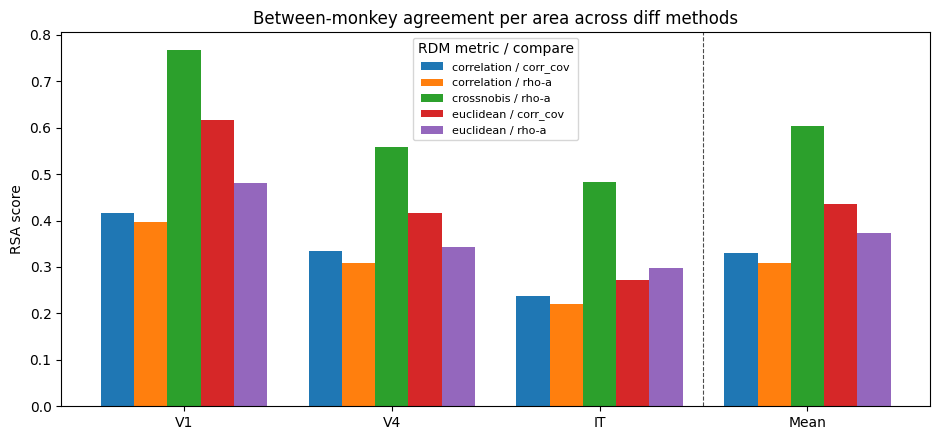

In [29]:
# Grouped bar chart: V1/V4/IT agreement plus the mean across areas.
combos = monkey.groupby(["rdm_metric", "compare_method"])
labels = list(combos.groups.keys())
x = np.arange(len(AREAS) + 1)
xlabels = AREAS + ["Mean"]
w = 0.8 / len(labels)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
for k, (key, g) in enumerate(combos):
    g = g.set_index("ROI").reindex(AREAS)
    values = g["rsa_score"].to_numpy(dtype=float)
    values = np.r_[values, np.nanmean(values)]
    ax.bar(x + k*w - 0.4 + w/2, values, w, label=f"{key[0]} / {key[1]}")

# Separate the area-level bars from the method means.
ax.axvline(2.5, color="black", ls="--", lw=0.8, alpha=0.7)
ax.axhline(0, color="black", lw=0.6)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.set_ylabel("RSA score")
ax.set_title("Between-monkey agreement per area across diff methods")
ax.legend(fontsize=8, title="RDM metric / compare")
plt.tight_layout(); plt.show()


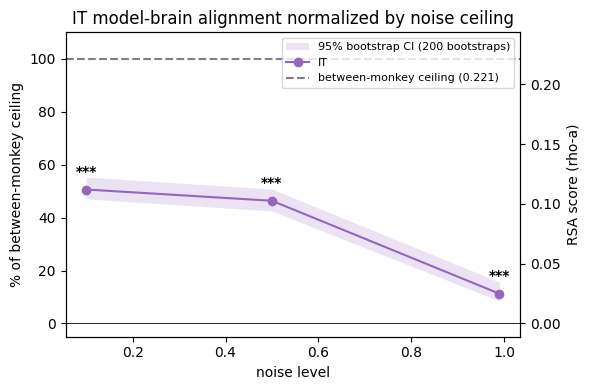

,noise,true_alignment_score,ci_low,ci_high,p_value
0,0.10,0.111982,0.104125,0.122378,0.000999
2,0.50,0.102589,0.094030,0.112397,0.000999
1,0.99,0.024935,0.018775,0.034688,0.000999


In [48]:
# IT only: model-brain alignment as % of the between-monkey noise ceiling, with bootstrap CIs
RESULTS = DATA
SIG_PATH = RESULTS / "Statistical_Significance.xlsx"
MONKEY_PATH = RESULTS / "Monkeys_Results.xlsx"
CI_PATH = RESULTS / "rsa_bootstrap_ci.csv"

sig = pd.read_excel(SIG_PATH)
monkey_results = pd.read_excel(MONKEY_PATH)
ci = pd.read_csv(CI_PATH)

ROI = "IT"
RDM_METRIC = "correlation"
COMPARE_METHOD = "rho-a"

it_sig = sig[
    (sig["roi"] == ROI)
    & (sig["rdm_metric"] == RDM_METRIC)
    & (sig["compare_method"] == COMPARE_METHOD)
].copy()
it_sig["noise"] = pd.to_numeric(it_sig["noise_degree"], errors="coerce")
it_sig = it_sig.dropna(subset=["noise"])

it_ci = ci[
    (ci["roi"] == ROI)
    & (ci["rdm_metric"] == RDM_METRIC)
    & (ci["compare_method"] == COMPARE_METHOD)
].copy()
it_ci["noise"] = pd.to_numeric(it_ci["noise_degree"], errors="coerce")

plot_df = (
    it_sig.merge(it_ci[["noise", "score", "ci_low", "ci_high", "n_bootstrap", "ci"]],
                 on="noise", how="left")
    .sort_values("noise")
)

ceiling = monkey_results[
    (monkey_results["ROI"] == ROI)
    & (monkey_results["rdm_metric"] == RDM_METRIC)
    & (monkey_results["compare_method"] == COMPARE_METHOD)
]["rsa_score"].iloc[0]

y = 100 * plot_df["true_alignment_score"] / ceiling
def pstars(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "n.s."

fig, ax = plt.subplots(figsize=(6, 4))
noise = plot_df["noise"].to_numpy(dtype=float)
y = y.to_numpy(dtype=float)
ci_low_pct = 100 * plot_df["ci_low"].to_numpy(dtype=float) / ceiling
ci_high_pct = 100 * plot_df["ci_high"].to_numpy(dtype=float) / ceiling

ax.fill_between(noise, ci_low_pct, ci_high_pct, color="tab:purple", alpha=0.18, linewidth=0,
                label=f"95% bootstrap CI ({int(plot_df['n_bootstrap'].dropna().iloc[0])} bootstraps)")
ax.plot(noise, y, "o-", color="tab:purple", label=ROI)

for noise, yi, p in zip(plot_df["noise"], y, plot_df["p_value"]):
    ax.annotate(pstars(p), (noise, yi), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, fontweight="bold")

ax.axhline(100, ls="--", color="gray", label=f"between-monkey ceiling ({ceiling:.3f})")
ax.axhline(0, color="black", lw=0.6)
ax.set_ylim(-5, 110)
ax.set_xlabel("noise level")
ax.set_ylabel("% of between-monkey ceiling")

ax_r = ax.twinx()
lo, hi = ax.get_ylim()
ax_r.set_ylim(lo / 100 * ceiling, hi / 100 * ceiling)
ax_r.set_ylabel("RSA score (rho-a)")

ax.set_title("IT model-brain alignment normalized by noise ceiling")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

plot_df[["noise", "true_alignment_score", "ci_low", "ci_high", "p_value"]]


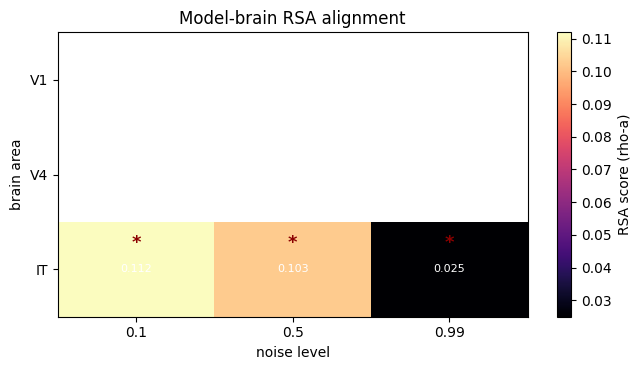

Missing result cells: [('V1', np.float64(0.1)), ('V1', np.float64(0.5)), ('V1', np.float64(0.99)), ('V4', np.float64(0.1)), ('V4', np.float64(0.5)), ('V4', np.float64(0.99))]


In [43]:
metric = "correlation"
compare = "rho-a"
SHOW_SIGNIFICANCE = True
P_THRESHOLD = 0.05

plot_sig = sig[(sig["rdm_metric"] == metric) & (sig["compare_method"] == compare)].copy()
plot_sig["noise"] = pd.to_numeric(plot_sig["noise_degree"], errors="coerce")
plot_sig = plot_sig.dropna(subset=["noise"])

noise_levels = sorted(plot_sig["noise"].unique())
heat = (
    plot_sig.pivot_table(index="roi", columns="noise", values="true_alignment_score", aggfunc="mean")
    .reindex(index=AREAS, columns=noise_levels)
)
pvals = (
    plot_sig.pivot_table(index="roi", columns="noise", values="p_value", aggfunc="min")
    .reindex(index=AREAS, columns=noise_levels)
)

fig, ax = plt.subplots(figsize=(1.15 * len(noise_levels) + 3.2, 3.8))
masked = np.ma.masked_invalid(heat.to_numpy(dtype=float))
im = ax.imshow(masked, aspect="auto", cmap="magma")

ax.set_xticks(range(len(noise_levels)))
ax.set_xticklabels([f"{n:g}" for n in noise_levels])
ax.set_yticks(range(len(AREAS)))
ax.set_yticklabels(AREAS)
ax.set_xlabel("noise level")
ax.set_ylabel("brain area")
ax.set_title("Model-brain RSA alignment")
fig.colorbar(im, ax=ax, label="RSA score (rho-a)")

for i, area in enumerate(AREAS):
    for j, noise in enumerate(noise_levels):
        value = heat.loc[area, noise]
        p = pvals.loc[area, noise]
        if pd.isna(value):
            continue
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white", fontsize=8)
        if SHOW_SIGNIFICANCE and pd.notna(p) and p < P_THRESHOLD:
            ax.text(j, i - 0.28, "*", ha="center", va="center", color="darkred", fontsize=13, fontweight="bold")

plt.tight_layout(); plt.show()

missing = heat.isna()
if missing.any().any():
    missing_cells = [(area, noise) for area in AREAS for noise in noise_levels if missing.loc[area, noise]]
    print("Missing result cells:", missing_cells)
